# Building a CNN model on our dataset

## Setup (imports & data loading, brought over from Pneumonia_detection.ipynb)

This reproduces the same imports, seed, transforms, and 60/20/20 train/val/test split used in `Pneumonia_detection.ipynb`, so the CNN is trained/evaluated on the exact same split as the baseline models.

In [1]:
import os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# set seed (matches Pneumonia_detection.ipynb so the train/val/test split lines up)
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [2]:
# imagenet_norm consists of the mean and std of the imagenet dataset
imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# Every image in our dataset will be resized to 224x224 and converted to tensors
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    imagenet_norm
])

# Data Augmentation on the train dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    imagenet_norm
])

In [3]:
batch_size = 64

# Load the original datasets
train_data_old = datasets.ImageFolder(root='./train', transform=transform)
val_data_old   = datasets.ImageFolder(root='./val', transform=transform)
test_data_old  = datasets.ImageFolder(root='./test', transform=transform)

# Merge them into one dataset
full_dataset = ConcatDataset([train_data_old, val_data_old, test_data_old])

In [4]:
total_len = len(full_dataset)
train_len = int(0.6 * total_len)
val_len = int(0.2 * total_len)
test_len = total_len - train_len - val_len

generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=generator
)

# Train dataset gets AUGMENTATION
train_data.dataset.transform = train_transform

# Val/test get ONLY resizing+normalization
val_data.dataset.transform = transform
test_data.dataset.transform = transform

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [5]:
# The architecture now lives in app/model.py, so the notebook and the FastAPI
# service both train/serve the exact same class definition.
from app.model import pnuemoniaCNN

# You may want to verify the architecture of CNN
model = pnuemoniaCNN().to(device)
model

pnuemoniaCNN(
  (conv10): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(10, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv16): Conv2d(5, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

In [6]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.005)  # Use a low learning rate for this dataset

model = model.to(device)


In [7]:
# Training Loop

from tqdm import tqdm # This library shows loading bar for each training epoch
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Training Epoch {epoch}/{epochs}")
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, pred = torch.max(outputs, 1)
        correct += pred.eq(labels).sum().item()
        total += images.size(0)

        pbar.set_postfix(loss=loss.item(), accuracy=f"{(correct/total)*100:.2f}%")

    return running_loss / len(train_loader.dataset), (correct / total) * 100

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    vbar = tqdm(val_loader, desc=f"Validation Epoch {epoch}/{epochs}")

    with torch.no_grad():
        for images, labels in vbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, pred = torch.max(outputs, 1)
            correct += pred.eq(labels).sum().item()
            total += images.size(0)

            vbar.set_postfix(val_loss=loss.item(), val_accuracy=f"{(correct/total)*100:.2f}%")

    return running_loss / len(val_loader.dataset), (correct / total) * 100

In [8]:
epochs = 7
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# Run the training epochs
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(va_loss)
    val_accs.append(va_acc)

Validation Epoch 7/7: 100%|██████████| 19/19 [00:10<00:00,  1.74it/s, val_accuracy=88.22%, val_loss=0.259]


In [9]:
import os

# Export trained weights for the FastAPI service (app/inference.py loads this file)
os.makedirs("artifacts", exist_ok=True)
torch.save(model.state_dict(), "artifacts/pneumonia_cnn.pt")
print("Saved weights to artifacts/pneumonia_cnn.pt")

Saved weights to artifacts/pneumonia_cnn.pt


In [10]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"[Chest X-Ray Pneumonia Test] Loss = {test_loss:.4f} | Acc = {test_acc:.2f}%")

Validation Epoch 7/7: 100%|██████████| 19/19 [00:11<00:00,  1.68it/s, val_accuracy=88.23%, val_loss=0.218]

[Chest X-Ray Pneumonia Test] Loss = 0.2878 | Acc = 88.23%


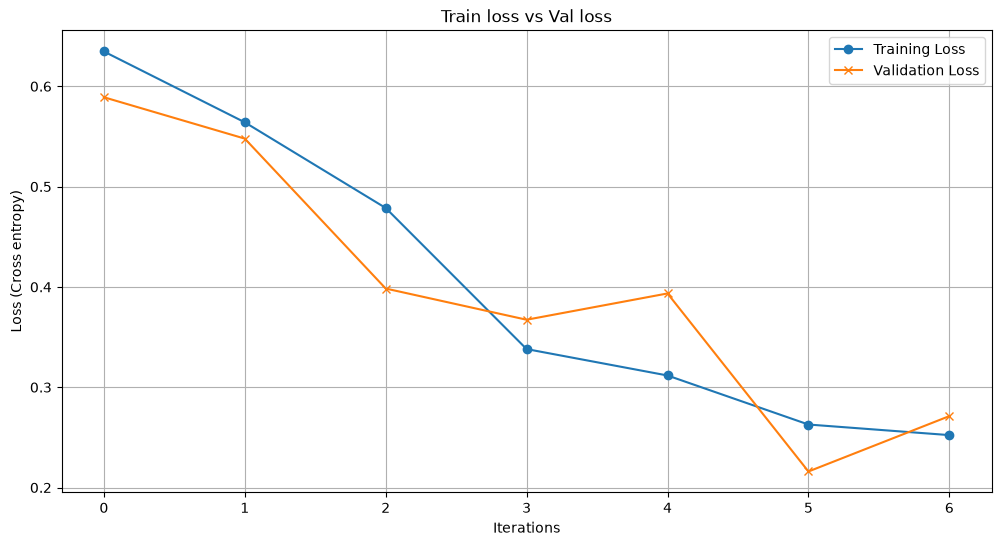

In [11]:
# CODE HERE
# Plot the "Training vs Validation Loss"
# --- Plotting Results ---
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.title('Train loss vs Val loss')
plt.xlabel('Iterations')
plt.ylabel('Loss (Cross entropy)')
plt.legend()
plt.grid(True)
plt.show()



# Error Analysis

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="CNN Error Analysis on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print("CNN Classification Report on Test Set:")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))


CNN Error Analysis on Test Set: 100%|██████████| 19/19 [00:11<00:00,  1.68it/s]

CNN Classification Report on Test Set:
              precision    recall  f1-score   support

      Normal       0.73      0.93      0.82       329
   Pneumonia       0.97      0.86      0.91       843

    accuracy                           0.88      1172
   macro avg       0.85      0.90      0.86      1172
weighted avg       0.90      0.88      0.89      1172



<Figure size 400x400 with 0 Axes>

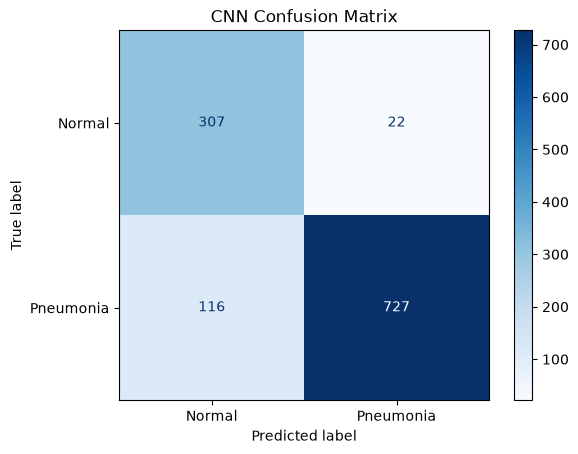

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()

In [14]:
# Undo the image normalizaton before displaying misclassified images
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(img_tensor):
    img = img_tensor.cpu().clone()
    img = img * imagenet_std + imagenet_mean
    img = torch.clamp(img, 0, 1)
    return img

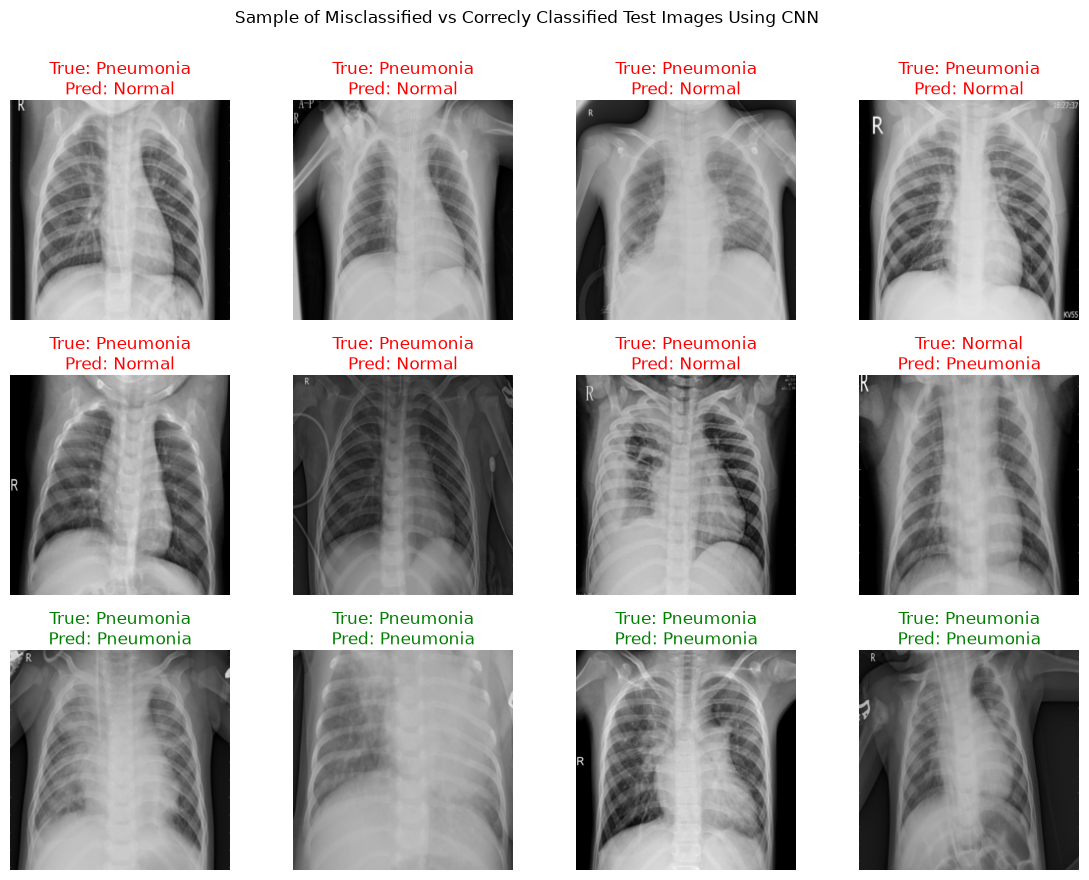

In [15]:
mis_images = [] # all misclassified images
mis_true = [] # true labels for misclassified images
mis_pred = [] # predicted labels for misclassified 

correct_images = []
correct_true = []
correct_pred = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting misclassified samples"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        mask = preds != labels
        mask_correct = preds == labels
        
        mis_images.append(images[mask].cpu())
        mis_true.extend(labels[mask].cpu().numpy())
        mis_pred.extend(preds[mask].cpu().numpy())

        correct_images.append(images[mask_correct].cpu())
        correct_true.extend(labels[mask_correct].cpu().numpy())
        correct_pred.extend(preds[mask_correct].cpu().numpy())

    mis_images = torch.cat(mis_images, dim=0)
    correct_images = torch.cat(correct_images, dim=0)
    
    # Shuffle through the misclassified images
    mis_indices = torch.randperm(len(mis_images))
    mis_images = mis_images[mis_indices]
    mis_true = np.array(mis_true)[mis_indices]
    mis_pred = np.array(mis_pred)[mis_indices]

    corr_indices = torch.randperm(len(correct_images))
    correct_images = correct_images[corr_indices]
    correct_true = np.array(correct_true)[corr_indices]
    correct_pred = np.array(correct_pred)[corr_indices]
    
    num_mis_display = min(8, len(mis_images)) # Display up to 8 misclassified images
    num_corr_display = min(4, len(correct_images)) # Display some correctly classified images for comparison
    plt.figure(figsize=(14, 10))
    
    for i in range(num_mis_display):
        plt.subplot(3, 4, i + 1)
        img = denorm(mis_images[i])
        img = img.permute(1, 2, 0).numpy()

        plt.imshow(img.squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        plt.axis("off")
        true_label = "Normal" if mis_true[i] == 0 else "Pneumonia"
        pred_label = "Normal" if mis_pred[i] == 0 else "Pneumonia"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color="red", pad=4)

    offset = num_mis_display
    for i in range(num_corr_display):
        plt.subplot(3, 4, offset + i + 1)
        img = denorm(correct_images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img.squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        plt.axis("off")
        true_label = "Normal" if correct_true[i] == 0 else "Pneumonia"
        pred_label = "Normal" if correct_pred[i] == 0 else "Pneumonia"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color="green", pad=4)

    plt.suptitle("Sample of Misclassified vs Correcly Classified Test Images Using CNN", y=0.97)
    plt.subplots_adjust(top=0.88, hspace=0.25)
    plt.show()

CNN Performance Summary:


,Value
Validation Accuracy,0.8822
Test Accuracy,0.8823
F1 Score (Test),0.9133


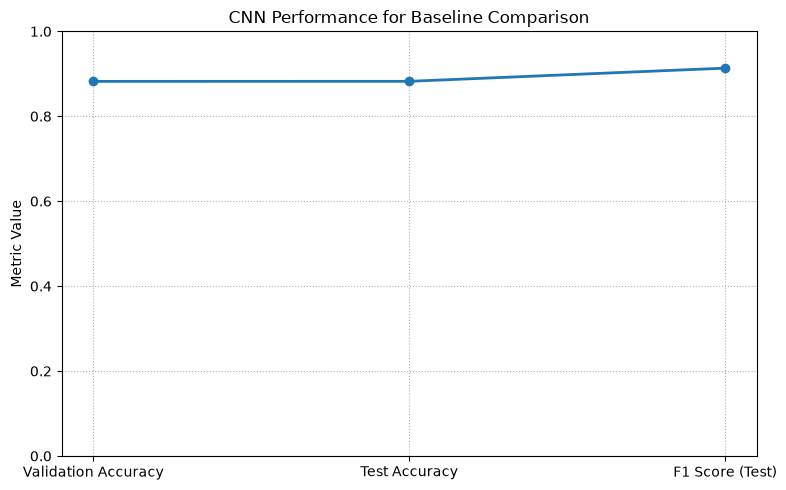

In [16]:
from sklearn.metrics import f1_score
import pandas as pd

cnn_val_acc = val_accs[-1] / 100.0    
cnn_test_acc = test_acc / 100.0      
cnn_f1 = f1_score(all_labels, all_preds)

print("CNN Performance Summary:")

cnn_metrics = {
    "Validation Accuracy": cnn_val_acc,
    "Test Accuracy": cnn_test_acc,
    "F1 Score (Test)": cnn_f1
}

cnn_df = pd.DataFrame.from_dict(cnn_metrics, orient='index', columns=['Value']).round(4)
display(cnn_df)

labels = list(cnn_metrics.keys())
values = list(cnn_metrics.values())

plt.figure(figsize=(8, 5))
plt.plot(labels, values, marker='o', linewidth=2)
plt.title('CNN Performance for Baseline Comparison')
plt.ylabel('Metric Value')
plt.ylim(0, 1)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()